<a href="https://colab.research.google.com/github/Flick404/CarbonX/blob/main/Text_Classification_Practice_Notebook_completed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text Classification Practice Notebook

In this notebook you will apply what you have learned to develop a **sentiment classifier**.

Main objectives:

1. **Data Collection and Preparation**: Use a suitable dataset for sentiment analysis.
2. **Text Processing**: Employ spaCy for text cleaning and preparation.
3. **Feature Extraction**: Apply TF‑IDF to transform texts into a model-friendly format.
4. **Modeling**: Implement and train a **Naive Bayes** and a **Logistic Regression** classifier using scikit‑learn.
5. **Evaluation**: Assess and compare the performance of the classifiers.

We'll use the IMDB Reviews dataset because it is widely used for sentiment analysis and has clean binary labels (negative/positive).


I will give you the code to prepare the dataset. Since it is a very large dataset, we'll use **only a subset of 5,000 reviews**, randomly sampled from the IMDB train split.

This step can take more time the first time you execute it since we have to download the data.


In [ ]:
%%time
import tensorflow_datasets as tfds
import pandas as pd

full_dataset, info = tfds.load('imdb_reviews', with_info=True, as_supervised=True)
imdb_dataset = full_dataset['train']
imdb_dataset = tfds.as_dataframe(imdb_dataset, info).sample(n=5000, random_state=2024)
print(imdb_dataset.head())

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.9M7FX1_1.0.0/imdb_reviews-train.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.9M7FX1_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.9M7FX1_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.
       label                                               text
20556      0  b"What a bad movie. I'm really surprised that ...
23551      1  b"one of the funnest mario's i've ever played....
17408      0  b'"Whipped" is one of the most awful films of ...
11940      0  b"Way to go ace! You just made a chilling, gro...
9385       0  b'I just saw "If\xc2\x85" I can remember the a...
CPU times: user 58.7 s, sys: 3.94 s, total: 1min 2s
Wall time: 1min 21s


Next, divide the sampled reviews into **train / validation / test** sets using `train_test_split`.  
Use a fixed random seed (`2024`) and keep the split **stratified** by the sentiment label so positives/negatives stay balanced.


In [ ]:
# Step 1: Train / Test Split
from sklearn.model_selection import train_test_split

# TFDS -> pandas dataframe typically has columns: 'text' and 'label'
# We keep the split stratified so positives/negatives are balanced.
train_df, test_df = train_test_split(
    imdb_dataset,
    test_size=0.2,
    random_state=2024,
    stratify=imdb_dataset['label']
)

# (Optional) create a small validation split from the training data
train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=2024,
    stratify=train_df['label']
)

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
train_df.head()


Train: 3,200 | Val: 800 | Test: 1,000


,label,text
20093,0,b'You may want to know up front that I am not ...
17946,0,"b'I am a student of film, and have been for se..."
5359,0,"b""As a member of the cast, I was a member of t..."
11697,0,"b""Randolph Scott is leaving the USA for the gr..."
12577,1,"b""This is a great movie for any fan of Hong Ko..."


Once we have the datasets, we can start preprocessing the text using **spaCy**.

You already have a basic scaffold below. Your goal is to:
- decode bytes → string
- remove URLs / HTML artifacts
- tokenize
- lemmatize
- lowercase
- remove stopwords, punctuation, and numbers

Finally, apply the preprocessing function to each dataset and store the result in a new `processed_text` column.


In [ ]:
%%time
import re
import spacy

# If you're running this in Colab and the model isn't available, uncomment:
# !python -m spacy download en_core_web_sm

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])  # faster, we only need tokenization/lemmatization

def clean_and_decode_text(text):
    """TFDS may provide bytes; convert to str."""
    if isinstance(text, bytes):
        text = text.decode("utf-8", errors="ignore")
    return str(text)

_url_re = re.compile(r"https?://\S+|www\.\S+", re.IGNORECASE)
_html_re = re.compile(r"<.*?>")

def preprocess_text(text):
    """Basic, robust preprocessing:
    - decode bytes
    - strip URLs / HTML
    - spaCy tokenize + lemmatize
    - lowercase
    - remove stopwords, punctuation, spaces, numbers
    """
    text = clean_and_decode_text(text)
    text = _html_re.sub(" ", text)
    text = _url_re.sub(" ", text)
    text = text.replace("\n", " ").replace("\t", " ")
    text = re.sub(r"\s+", " ", text).strip()

    doc = nlp(text)

    tokens = []
    for tok in doc:
        if tok.is_stop or tok.is_punct or tok.is_space:
            continue
        if tok.like_num:
            continue
        lemma = tok.lemma_.lower().strip()
        if not lemma or lemma == "-pron-":
            continue
        # keep words with at least 2 characters (drops stray letters)
        if len(lemma) < 2:
            continue
        tokens.append(lemma)

    return " ".join(tokens)

# Apply the preprocessing to each review
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["processed_text"] = train_df["text"].apply(preprocess_text)
val_df["processed_text"] = val_df["text"].apply(preprocess_text)
test_df["processed_text"] = test_df["text"].apply(preprocess_text)

train_df[["processed_text", "label"]].head()


CPU times: user 1min 57s, sys: 507 ms, total: 1min 57s
Wall time: 2min 1s


,processed_text,label
20093,want know mormon unlike good number review fil...,0
17946,student film year concept cyber kung fu satiri...,0
5359,member cast member band basketball game like l...,0
11697,randolph scott leave usa green pasture canada ...,0
12577,great movie fan hong kong action movie aside l...,1


Once the data is prepared, extract features using **TF–IDF**, then train and compare two models:
1. **Multinomial Naive Bayes**
2. **Logistic Regression**

We'll use a validation set to pick the better model, then evaluate once on the test set.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Step 2: Feature Extraction (TF-IDF)
# Fit ONLY on train to avoid leakage.
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2
)

X_train = tfidf.fit_transform(train_df["processed_text"])
X_val = tfidf.transform(val_df["processed_text"])
X_test = tfidf.transform(test_df["processed_text"])

y_train = train_df["label"].astype(int).values
y_val = val_df["label"].astype(int).values
y_test = test_df["label"].astype(int).values

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)


X_train shape: (3200, 20000)
X_val shape: (800, 20000)
X_test shape: (1000, 20000)


In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Step 3: Model Building
nb_model = MultinomialNB()
lr_model = LogisticRegression(
    max_iter=2000,
    n_jobs=None,          # keep compatible across sklearn versions
    solver="lbfgs"
)

# Train
nb_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)

# Predict (val first for model selection)
nb_val_pred = nb_model.predict(X_val)
lr_val_pred = lr_model.predict(X_val)

print("Done training. Predictions ready.")


Done training. Predictions ready.


Now evaluate the models.

Recommended flow:
1. Evaluate on the **validation set** to choose the better model (avoid test-set leakage).
2. Pick the best model using **F1-score** (or another metric you justify).
3. Evaluate that single chosen model once on the **test set**.
4. Inspect the confusion matrix and a classification report to understand error modes.


MultinomialNB (Validation)
Accuracy : 0.8575
Precision: 0.8554
Recall   : 0.8596
F1-score : 0.8575


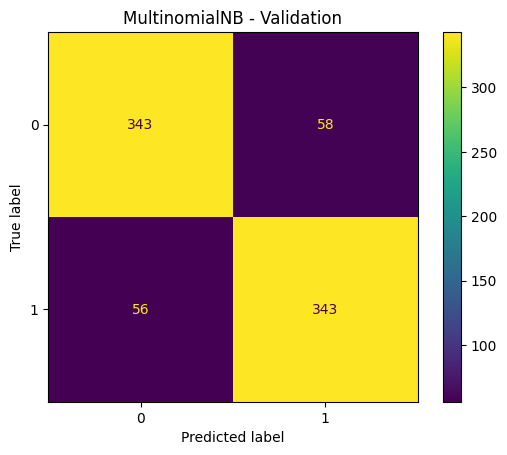

LogisticRegression (Validation)
Accuracy : 0.8438
Precision: 0.8100
Recall   : 0.8972
F1-score : 0.8514


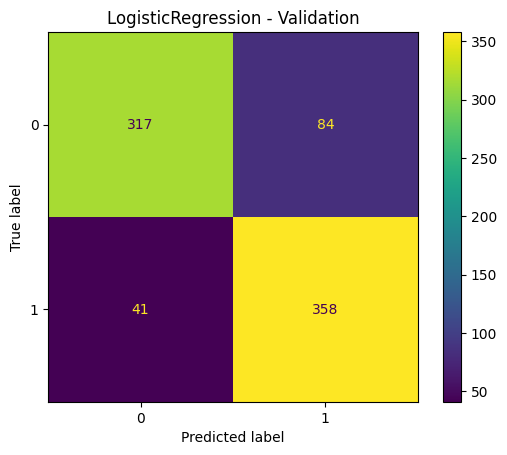

In [ ]:
# Step 4: Model Evaluation
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import metrics

def report_metrics(y_true, y_pred, title=""):
    acc = metrics.accuracy_score(y_true, y_pred)
    prec = metrics.precision_score(y_true, y_pred, zero_division=0)
    rec = metrics.recall_score(y_true, y_pred, zero_division=0)
    f1 = metrics.f1_score(y_true, y_pred, zero_division=0)
    if title:
        print(title)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

def plot_confusion(y_true, y_pred, title="Confusion matrix"):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(values_format="d")
    plt.title(title)
    plt.show()

# Validation performance
nb_val_scores = report_metrics(y_val, nb_val_pred, title="MultinomialNB (Validation)")
plot_confusion(y_val, nb_val_pred, title="MultinomialNB - Validation")

lr_val_scores = report_metrics(y_val, lr_val_pred, title="LogisticRegression (Validation)")
plot_confusion(y_val, lr_val_pred, title="LogisticRegression - Validation")


Best model by validation F1: MultinomialNB


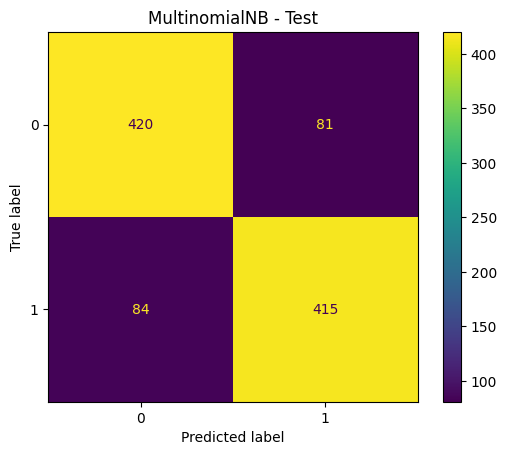

In [ ]:
# Choose the model with the better validation F1 (tie-breaker: accuracy)
best_model_name = "LogisticRegression" if lr_val_scores["f1"] >= nb_val_scores["f1"] else "MultinomialNB"
best_model = lr_model if best_model_name == "LogisticRegression" else nb_model

print("Best model by validation F1:", best_model_name)

best_test_pred = best_model.predict(X_test)
plot_confusion(y_test, best_test_pred, title=f"{best_model_name} - Test")


In [ ]:
from sklearn.metrics import classification_report

test_scores = report_metrics(y_test, best_test_pred, title=f"{best_model_name} (Test)")
print()
print("Classification report (Test):")
print(classification_report(y_test, best_test_pred, digits=4))


MultinomialNB (Test)
Accuracy : 0.8350
Precision: 0.8367
Recall   : 0.8317
F1-score : 0.8342

Classification report (Test):
              precision    recall  f1-score   support

           0     0.8333    0.8383    0.8358       501
           1     0.8367    0.8317    0.8342       499

    accuracy                         0.8350      1000
   macro avg     0.8350    0.8350    0.8350      1000
weighted avg     0.8350    0.8350    0.8350      1000

